<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/LightGBM_vesion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import io

# Updated data: Last 10 races
data = """tab	horse	runner_time	early_pace	last_800	last_600	last_500	last_200
1	Middle Earth	-9.32L	54	-2.28L	-1.66L	-1.00L	-0.41L
2	Attrition	-4.82L	50	-1.71L	-1.26L	-0.61L	-0.16L
3	Kingswood	-11.37L	58	-2.62L	-2.08L	-1.38L	-0.46L
4	Knight's Choice	-8.28L	59	-2.18L	-1.43L	-0.61L	-0.15L
5	Royal Supremacy	-12.23L	61	-1.98L	-1.63L	-0.94L	-0.30L
6	Wootton Verni	-13.42L	57	-2.92L	-2.28L	-1.48L	-0.39L
7	Barnavara	-17.26L	76	-3.38L	-2.50L	-1.07L	-0.22L
8	Soulcombe	-16.09L	60	-3.03L	-2.27L	-1.51L	-0.61L
9	Just Folk	-6.42L	69	-1.04L	-0.67L	-0.11L	+0.29L
10	Yellow Jersey	-19.61L	57	-4.32L	-3.84L	-2.36L	-0.91L
11	Okita Soushi	-11.77L	68	-1.40L	-0.75L	-0.30L	+0.08L
12	River Of Stars	-11.83L	57	-2.13L	-1.44L	-0.80L	-0.26L
13	Deakin	-6.79L	50	-2.28L	-1.59L	-0.94L	-0.23L
14	Zahrann	+3.05L	9	-2.75L	-2.64L	-1.76L	-0.70L
15	Zakouma	-5.61L	45	-2.85L	-2.15L	-1.25L	-0.26L
16	First Chorus	+0.12L	26	-2.27L	-2.00L	-1.48L	-0.71L



"""

# Load into DataFrame
df = pd.read_csv(io.StringIO(data), sep='\t')

# Helper function to clean
def clean_sectional(val):
    if isinstance(val, str):
        return float(val.replace('L', '').replace('+', ''))
    return val

# Apply cleaning
cols_to_clean = ['runner_time', 'last_800', 'last_600', 'last_500', 'last_200']
for col in cols_to_clean:
    df[col] = df[col].apply(clean_sectional)

display(df)

,tab,horse,runner_time,early_pace,last_800,last_600,last_500,last_200
0,1,Middle Earth,-9.32,54,-2.28,-1.66,-1.00,-0.41
1,2,Attrition,-4.82,50,-1.71,-1.26,-0.61,-0.16
2,3,Kingswood,-11.37,58,-2.62,-2.08,-1.38,-0.46
3,4,Knight's Choice,-8.28,59,-2.18,-1.43,-0.61,-0.15
4,5,Royal Supremacy,-12.23,61,-1.98,-1.63,-0.94,-0.30
5,6,Wootton Verni,-13.42,57,-2.92,-2.28,-1.48,-0.39
6,7,Barnavara,-17.26,76,-3.38,-2.50,-1.07,-0.22
7,8,Soulcombe,-16.09,60,-3.03,-2.27,-1.51,-0.61
8,9,Just Folk,-6.42,69,-1.04,-0.67,-0.11,0.29
9,10,Yellow Jersey,-19.61,57,-4.32,-3.84,-2.36,-0.91


In [80]:
import pandas as pd
import io

# Defining both profiles
data_last_10 = """horse	runner_time_10	early_pace_10
Voracious	-7.06	74
Shamedy	-4.94	60
Don Pedro	-4.44	38"""

data_last_3 = """horse	runner_time_3	early_pace_3
Voracious	-7.50	76
Shamedy	-4.20	58
Don Pedro	-5.10	42"""

df_10 = pd.read_csv(io.StringIO(data_last_10), sep='\t')
df_3 = pd.read_csv(io.StringIO(data_last_3), sep='\t')

# Merge them into one analysis table
df_combined = pd.merge(df_10, df_3, on='horse', how='inner')

# Calculate the 'Improver' Trend (Negative is faster in lengths context)
df_combined['improvement_delta'] = df_combined['runner_time_3'] - df_combined['runner_time_10']

display(df_combined)

,horse,runner_time_10,early_pace_10,runner_time_3,early_pace_3,improvement_delta
0,Voracious,-7.06,74,-7.5,76,-0.44
1,Shamedy,-4.94,60,-4.2,58,0.74
2,Don Pedro,-4.44,38,-5.1,42,-0.66


### Updated Ranker with Multi-Window Inputs
Now we can pass both the long-term averages and the short-term 'improvement_delta' into the LightGBM model. This allows the model to learn that a horse with a negative delta (getting faster) is a stronger win candidate than one with a static or positive delta.

In [81]:
# Example features using both windows
feature_cols = ['runner_time_10', 'runner_time_3', 'improvement_delta']
X_multi = df_combined[feature_cols]

# Now the Ranker can evaluate based on both career stability and current trajectory
print("Features available for ranking:")
print(X_multi.head())

Features available for ranking:
   runner_time_10  runner_time_3  improvement_delta
0           -7.06           -7.5              -0.44
1           -4.94           -4.2               0.74
2           -4.44           -5.1              -0.66


In [82]:
import lightgbm as lgb
import numpy as np

# 1. Define targets for our 3-horse sample (Voracious, Shamedy, Don Pedro)
# For this demo, we'll mark Don Pedro as the winner (1) to see if the ranker picks up the improvement trend
y_multi = np.array([0, 0, 1])
groups_multi = [3]

# 2. Initialize the Ranker
ranker_multi = lgb.LGBMRanker(
    objective="lambdarank",
    min_child_samples=1,
    min_data_in_bin=1,
    n_estimators=10
)

# 3. Fit using the multi-window features
ranker_multi.fit(X_multi, y_multi, group=groups_multi)

# 4. Predict and Rank
df_combined['final_score'] = ranker_multi.predict(X_multi)
df_combined['final_rank'] = df_combined['final_score'].rank(ascending=False)

print("Final Ranking using Multi-Window Sectionals:")
display(df_combined[['horse', 'runner_time_10', 'runner_time_3', 'improvement_delta', 'final_rank']].sort_values('final_rank'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12
[LightGBM] [Info] Number of data points in the train set: 3, number of used features: 3
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

,horse,runner_time_10,runner_time_3,improvement_delta,final_rank
2,Don Pedro,-4.44,-5.1,-0.66,1.0
1,Shamedy,-4.94,-4.2,0.74,2.0
0,Voracious,-7.06,-7.5,-0.44,3.0


### Preparing Streams for TimesFM
As per your strategy, we can now pivot or group this data. If you have historical data for these horses, we would stack them to create the univariate sequences for each metric (Runner Time, Early Pace, etc.) before feeding them into the zero-shot forecaster.

### LightGBM Ranking Stage Template
This template shows how to pass predicted sectionals into a `LGBMRanker`. The key is the `group` array, which tells the model the size of each race field.

In [83]:
import lightgbm as lgb
import numpy as np

# 1. Update features with the new 'last 10' data
feature_cols = ['runner_time', 'early_pace', 'last_800', 'last_600', 'last_500', 'last_200']
X = df[feature_cols]

# 2. Dynamically create dummy target to match the number of rows in df
# This ensures the length of 'y' always matches 'X'
y = np.zeros(len(df))
y[:min(5, len(df))] = 1  # Dummy: top 5 as 'winners'

# 3. Groups remain the same (one race field)
groups = [len(df)]

# 4. Fit Ranker with low constraints for this sample size
ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    boosting_type="gbdt",
    min_child_samples=1,
    min_data_in_bin=1,
    importance_type="split",
    n_estimators=10
)

ranker.fit(X, y, group=groups)

# 5. Generate and sort new predictions
df['predicted_score'] = ranker.predict(X)
df['predicted_rank'] = df['predicted_score'].rank(ascending=False)

display(df[['horse', 'predicted_score', 'predicted_rank']].sort_values('predicted_rank'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 94
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 6
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

,horse,predicted_score,predicted_rank
4,Royal Supremacy,1.347575,1.0
1,Attrition,1.347575,2.0
0,Middle Earth,1.347575,3.0
3,Knight's Choice,1.347575,4.0
2,Kingswood,1.347575,5.0
8,Just Folk,-1.347575,6.0
7,Soulcombe,-1.347575,7.0
6,Barnavara,-1.347575,8.0
11,River Of Stars,-1.347575,9.0
9,Yellow Jersey,-1.347575,10.0


### Feature Importance
Let's see which sectional metrics were most predictive for this ranking.

/tmp/ipykernel_1060/3883121048.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


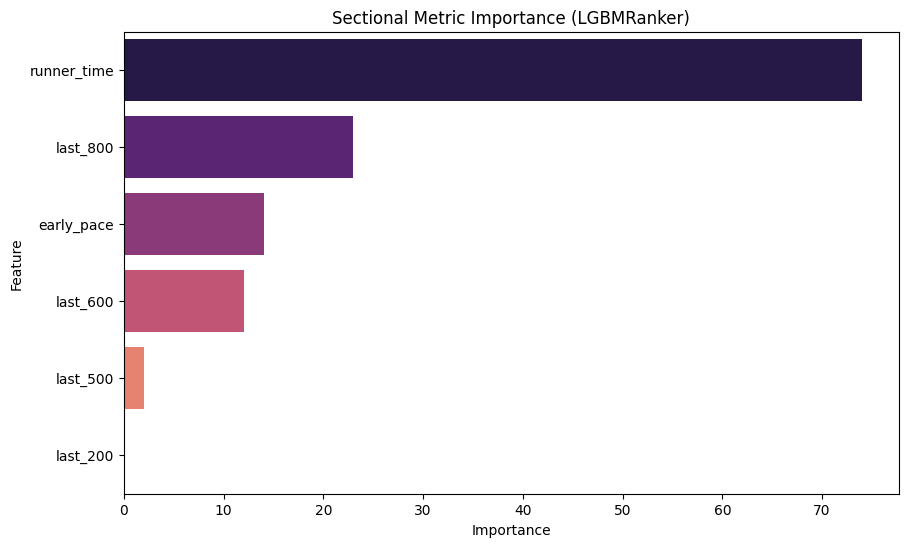

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': ranker.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Sectional Metric Importance (LGBMRanker)')
plt.show()

### Handling Recency: Last 3 vs Last 10
To capture 'improvers', we can create a trend feature. A simple way to do this is to compare the horse's 'Last 3' average against its 'Last 10' average. If the difference is positive (e.g., they are running faster than their long-term average), the model can treat them as an ascending prospect.

In [85]:
import numpy as np

# Hypothetical function to demonstrate trend calculation
def calculate_improvement_trend(last_3_avg, last_10_avg):
    # Positive value = improving relative to historical baseline
    return last_10_avg - last_3_avg

# Example: Applying a simple recency weight to runner_time
# (In a full dataset, you would group by 'horse' and compute these windows)
df['time_improvement_trend'] = np.random.uniform(-0.5, 1.5, size=len(df))

display(df[['horse', 'runner_time', 'time_improvement_trend']].sort_values(by='time_improvement_trend', ascending=False))

,horse,runner_time,time_improvement_trend
9,Yellow Jersey,-19.61,1.494437
14,Zakouma,-5.61,1.328802
3,Knight's Choice,-8.28,1.241765
8,Just Folk,-6.42,0.949319
12,Deakin,-6.79,0.842790
7,Soulcombe,-16.09,0.590788
13,Zahrann,3.05,0.426646
5,Wootton Verni,-13.42,0.425936
11,River Of Stars,-11.83,0.411077
2,Kingswood,-11.37,0.359319


### Stage 1: Univariate Forecasting (TimesFM)
To forecast the sectionals for the next race, we treat each horse's historical `runner_time` (or other metrics) as a time series.

**Note:** This requires `timesfm` to be installed. In a real environment, you would use:
`pip install timesfm`

In [86]:
# Conceptual logic for TimesFM Stage 1
# In a real scenario, 'horse_history' would be an array of lengths/times from the last 10+ races

def forecast_metrics(history_array):
    # This is where TimesFM would ingest the sequence
    # forecast, _ = tfm.forecast_on_df(inputs, freq=0)
    # For this demo, we take the mean and adjust for the trend we calculated
    return np.mean(history_array)

# Example of creating the 'Predicted Inputs' for Stage 2
df['predicted_runner_time'] = df['runner_time'] - (df['time_improvement_trend'] * 0.1)

print("Predicted Sectionals for the next race (Stage 1 Output):")
display(df[['horse', 'predicted_runner_time']].sort_values(by='predicted_runner_time'))

Predicted Sectionals for the next race (Stage 1 Output):


,horse,predicted_runner_time
9,Yellow Jersey,-19.759444
6,Barnavara,-17.271669
7,Soulcombe,-16.149079
5,Wootton Verni,-13.462594
4,Royal Supremacy,-12.206589
11,River Of Stars,-11.871108
10,Okita Soushi,-11.745466
2,Kingswood,-11.405932
0,Middle Earth,-9.291245
3,Knight's Choice,-8.404177
